# Climate Change Risks Keywords

## KeyBERT

As stated in the documentation, KeyBERT is a user-friendly keyword extraction library leveraging BERT embedding to create keywords and keyphrases that are most similar to a document. This is typically what we want to achieve here. Let's install it first:

In [ ]:
!pip install keybert

### KeyBERT in a Nutschell

To illustrate how KeyBERT works under the hood, this figure from the KeyBERT documentation does a far better job than me:

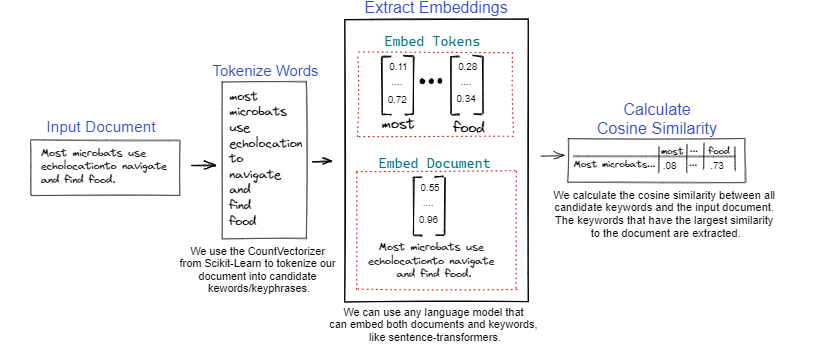


In a first step, we proceed to a document embedding (ie. transformed a document into a numerical vector representation, to keep the explanation short). Then, we proceed to the same step on each keywords / keyphrases. The final step involves the computation of cosine similarity (distance between the numerical vector representation of the document and the keyword / keyphrase) between all candidate keywords / keyphrases and the document. And voilà!

### Basic Usage

Let's try a first minimal example:

In [9]:
doc = """
Physical risks resulting from climate change can be event driven (acute) or longer-term shifts 
(chronic) in climate patterns. Physical risks may have financial implications for organizations, such 
as direct damage to assets and indirect impacts from supply chain disruption. Organizations’ 
financial performance may also be affected by changes in water availability, sourcing, and quality; 
food security; and extreme temperature changes affecting organizations’ premises, operations, 
supply chain, transport needs, and employee safety.
"""

In [4]:
from keybert import KeyBERT

kw_model = KeyBERT()
keywords = kw_model.extract_keywords(doc, highlight=True)

Physical risks resulting from climate change can be event driven acute or longer term shifts chronic in climate 
patterns Physical risks may have financial implications for organizations such as direct damage to assets and 
indirect impacts from supply chain disruption Organizations financial performance may also be affected by changes 
in water availability sourcing and quality food security and extreme temperature changes affecting organizations 
premises operations supply chain transport needs and employee safety

We can change the set `keyphrase_ngram_range` to set the length of the keywords/keyphrases we are looking for. For example, to get keyphrases we can set `keyphrase_ngram_range` to (1,2) if we want keyphrases up to 2 words:

In [12]:
keywords = kw_model.extract_keywords(doc, keyphrase_ngram_range = (1,2), stop_words = 'english', highlight=True)

Physical risks from climate change be event driven acute or longer term shifts chronic in climate patterns Physical
risks have financial implications for organizations such as direct damage to assets and indirect impacts from 
supply chain disruption Organizations financial performance may also be affected by changes in water availability 
sourcing and quality food security and extreme temperature changes affecting organizations operations supply chain 
transport needs and employee safety

And that's it! With 3 lines of code, you can already perform keywords / keyphrases extraction.
In order to better understand the possibility / caveats of the approach used with KeyBERT, we'll make a deep dive into the concept of extracting keywords with cosine similarity in the next part.

## Extracting Keywords with Cosine Similarity: a Deep Dive

While there are already well-known algorithms to extract keywords or keyphrases (for example, Hu et al. 2022 rely on a Latent Dirichlet Allocation (LDA) approach)), those approaches are based on the statistical properties of the text, rather than semantic similarity.

BERT is a bi-directional transformer model that transform phrases and documents to numerical vectors, capturing their meaning (the so-called embedding step we've refered to earlier).

KeyBERT leverages BERT capabilities to extract keywords based on their semantic similarity with the document, rather than fancy calculation about their frequencies. In our sense, this is a much sensible approach.

In this part, we will try to decompose the tasks done by the library KeyBERT in order to give you a better understanding of the algorithm. We'll start again with our first example:

In [2]:
doc = """
Physical risks resulting from climate change can be event driven (acute) or longer-term shifts 
(chronic) in climate patterns. Physical risks may have financial implications for organizations, such 
as direct damage to assets and indirect impacts from supply chain disruption. Organizations’ 
financial performance may also be affected by changes in water availability, sourcing, and quality; 
food security; and extreme temperature changes affecting organizations’ premises, operations, 
supply chain, transport needs, and employee safety.
"""

### Candidate Keywords/Keyphrases

Our first step is to create a list of candidate keywords or keyphrases. It means that we need to list all the words or phrases that meet our specifications. 

To select the potential keywords or keyphrases, we can use a `CountVectorizer` object from the library `sklearn`. There exist other vectorizers that we will encounter later. 

In terms of specifications, we can choose the length of the candidates we want to select with the `n_gram_range` parameter. For example, if we only want keywords (only one word), we can set it to `(1,1)`. If we want only phrases of 3 words, we can set it to `(3,3)`. If we want keywords AND keyphrases up to 3 words, we can set it to `(1,3)`.

Using `CountVectorizer`, we can also choose to drop stopwords ('and', 'the', etc.) by setting the argument `stop_words` to the language to use for dropping stopwords (ie. `"english"` here).

In [75]:
from sklearn.feature_extraction.text import CountVectorizer

n_gram_range = (1,1)
stop_words = "english"

# Extracting candidate keywords / keyphrases
count = CountVectorizer(ngram_range = n_gram_range, stop_words = stop_words).fit([doc])
candidates = count.get_feature_names_out()
print(len(candidates))
print(candidates)

42
['acute' 'affected' 'affecting' 'assets' 'availability' 'chain' 'change'
 'changes' 'chronic' 'climate' 'damage' 'direct' 'disruption' 'driven'
 'employee' 'event' 'extreme' 'financial' 'food' 'impacts' 'implications'
 'indirect' 'longer' 'needs' 'operations' 'organizations' 'patterns'
 'performance' 'physical' 'premises' 'quality' 'resulting' 'risks'
 'safety' 'security' 'shifts' 'sourcing' 'supply' 'temperature' 'term'
 'transport' 'water']


**EXERCISE**: At this stage, you should play around with the `n_gram_range` parameters in order to see which length gives you the more sensible candidates in your sense.

### Embeddings

Now, we will convert our list of candidates keywords / keyphrases and our document to numerical representation (ie. the embedding phase). 

Using **BERT** for this purpose gives us the advantage to obtain a numerical vector representing the meaning of the document and our candidates keywords. 

To generate BERT embeddings, we will use the package `sentence-transformers` (we'll do a deep dive on it in the topic modelling phase). 

We first need to install it:

In [ ]:
!pip install sentence-transformers

Using `sentence-transformers`, the step to transform our document and candidates keywords into numerical vectors is easy:

In [76]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('distilbert-base-nli-mean-tokens')
doc_embedding = model.encode([doc])
candidates_embeddings = model.encode(candidates)

The preceding code will first download a pre-trained large language model (ie. it will download the weights and architecture of the pre-trained model). Later, we will use another pre-trained model as `distilbert-base-nli-mean-tokens` is considered to be deprecated, but still is a good start for an illustration purpose.

Now let's have a look at the results:

In [46]:
print(candidates_embeddings.shape)
print(candidates_embeddings)

(42, 768)
[[-0.68191093 -0.8705937   0.05186352 ... -0.01992828  0.30117366
  -0.9494938 ]
 [-0.409016   -0.19909114 -0.2148618  ... -0.63437986  0.05151506
  -0.24857354]
 [-0.44906187 -0.21071787 -0.12306083 ... -0.5263949  -0.0626047
  -0.39275336]
 ...
 [-0.3307406  -0.03926637  0.3043534  ... -0.1757523  -0.15117037
   0.04834892]
 [-0.7669616   0.11929464  0.23707213 ... -0.0682606  -0.1006377
  -0.43792835]
 [-0.3425676  -0.0058108   0.7193826  ... -0.28569314 -0.8470111
   0.6572499 ]]


:We can see that the resulting candidates embeddings are of shape `(42, 768)`.
The first term corresponds to the number of candidates (42), while the second term corresponds to the dimension of the output layer from `Distillbert`. This is the dimension of the numerical representation of each of our candidates.

The same is true with our document embedding:

In [47]:
print(doc_embedding.shape)

(1, 768)


**EXERCISE**: Go to the [sentence-transformers list of pre-trained models](https://www.sbert.net/docs/pretrained_models.html) and choose another model in the list. Click on the model name and go to the corresponding `HuggingFace` model card. Go to the intended uses part to see for which task the model is intented. Take a look at the limit text length. Try to perform the embedding using another model. Take a look at the difference in terms of processing time with `%%time` and the output dimension.

### Cosine Similarity

The final step in the process involves the finding of the candidates keywords / keyphrases that are the most similar to the entire document.

To do so, we use the concept of cosine similarity. It is used to measure the similarity between two vectors by measuring the cosine of the angle between them. Let's illustrate this:

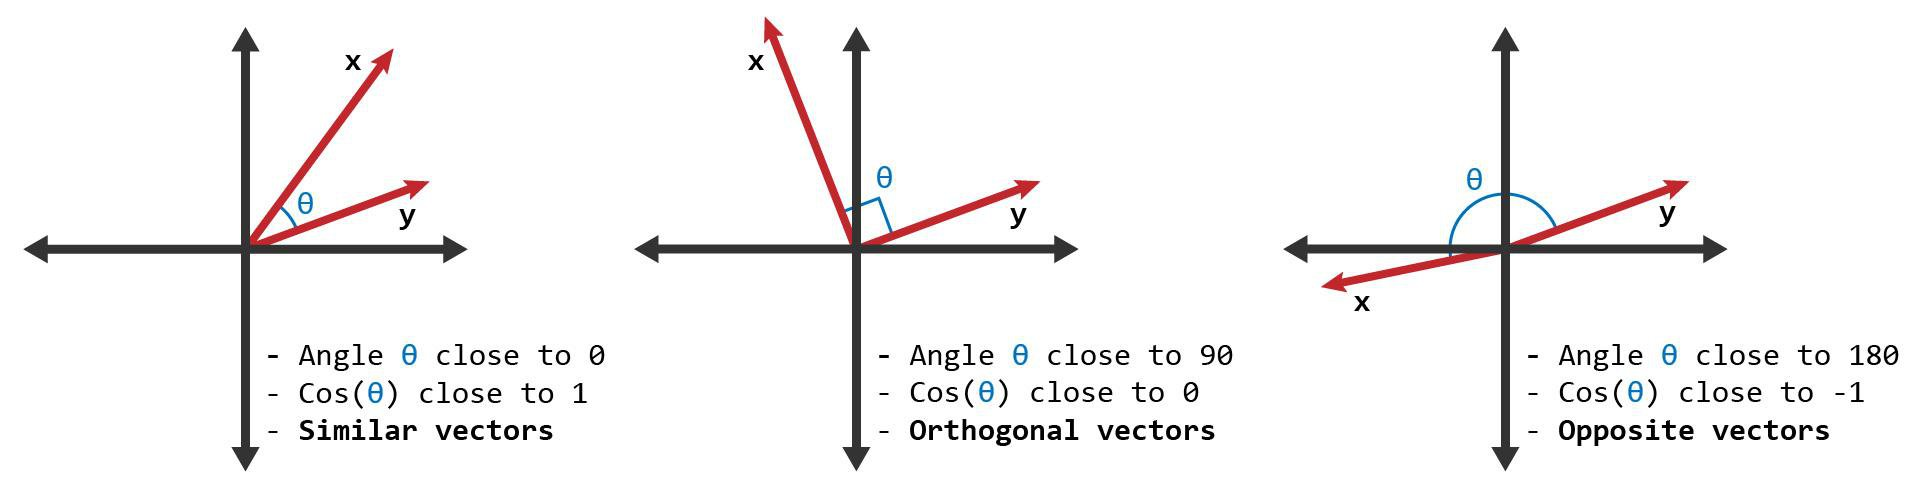


As our document and candidates keywords / keyphrases are embedded into numerical vectors of the same dimension, we can apply this concept in order to obtain the similarity between them:
- If the cosine is close to 1, it means that our candidate and our document have close similarity in their meaning (think about physical risks and a text about floods). 
- If the cosine is close to 0, the candidate and the document meanings are unrelated (think about physical risks and a text about bananas).
- If the cosine is close to -1, the candidate and the document meanings are opposite (think about physical risks and a text about green technologies opportunities).

We can use the function `cosine_similarity` from the library `sklearn` in order to easily compute the cosine similarity between our candidates and document embeddings:

In [89]:
from sklearn.metrics.pairwise import cosine_similarity

top_n = 5 
distances = cosine_similarity(doc_embedding, candidates_embeddings)
keywords = [candidates[index] for index in distances.argsort()[0][-top_n:]]
print(keywords)

['disruption', 'affected', 'affecting', 'impacts', 'climate']


And voilà! But these keywords are maybe too similar between themselves, even if they seem to represent quite well the meaning of the document.

We'll look in the next part how to add diversification into the keywords extraction.

**EXERCISE**: do the same process with `n_gram_range` is `(3,3)` in the `CountVectorizer` to see the difference!

### Diversification

Our selected keywords are really similar to each other (for example "affected" and "affecting") simply because those are the one that best represent the document. There is no reason why "affecting" would have a much lower similarity score than "affected" as the meaning is close.

But we would be happier if the resulting keywords could maybe higlight sub-types of physical risks such as acute and chronic risks for example. To do so, we need to increase the diversification of our keywords. 

There are two algorithms we can use to increase the diversification in our results:
- Max Sum Similarity
- Maximal Marginal Relevance

However, we need to keep in mind that by diversifying the resulting keywords, we make less likely our keywords to represent the entire document. Thus, the diversification is a delicate trade-off between the accuracy of keywords and the diversity between them.

#### Max Sum Similarity

With this algorithm, we want to maximize the candidate similarity to the document while minimizing the similarity between candidates. In other words, and taking our previous example, we still possibly want "affected" or "affecting" to be part of our keywords as they seem to have a high similarity score with the document, but don't want both at the same time!

We proceed in two steps:
- Select the top `nr_candidates` keywords / keyphrases
- From those candidates, select the `top_n` that are the least similar to each other

Let's see the code implementation:

In [49]:
import numpy as np
import itertools 

def max_sum_sim(doc_embedding, candidate_embeddings, candidates, top_n, nr_candidates):
    # Calculate distances and extract keywords
    distances = cosine_similarity(doc_embedding, candidate_embeddings)
    distances_candidates = cosine_similarity(candidate_embeddings, 
                                            candidate_embeddings)

    # Get top_n words as candidates based on cosine similarity
    words_idx = list(distances.argsort()[0][-nr_candidates:])
    words_vals = [candidates[index] for index in words_idx]
    distances_candidates = distances_candidates[np.ix_(words_idx, words_idx)]

    # Calculate the combination of words that are the least similar to each other
    min_sim = np.inf
    candidate = None
    for combination in itertools.combinations(range(len(words_idx)), top_n):
        sim = sum([distances_candidates[i][j] for i in combination for j in combination if i != j])
        if sim < min_sim:
            candidate = combination
            min_sim = sim

    return [words_vals[idx] for idx in candidate]



If we set up the `nr_candidates` equal to the number of final candidates `top_n`, we obviously obtain the same keywords than before:

In [50]:
print(max_sum_sim(doc_embedding, candidates_embeddings, candidates, top_n = 5, nr_candidates = 5))

['disruption', 'affected', 'affecting', 'impacts', 'climate']


But as we increase the `nr_candidates` parameter, we diversify our results:

In [51]:
print(max_sum_sim(doc_embedding, candidates_embeddings, candidates, top_n = 5, nr_candidates = 10))

['chronic', 'security', 'damage', 'disruption', 'climate']


The author of the KeyBERT library advises to not use a number of `nr_candidates` higher than 20% of the total number of unique words in the document, to still have sensible results.

**EXERCISE**: play around with `nr_candidates`, in combination with `ngram_range`!

#### Maximal Marginal Relevance

This algorithm to diversify our results by:
- selecting the keyword/keyphrase that is the most similar to the document
- iteratively selecting new candiates that are both similar to the document and not similar to the already selected keywords / keyphrases

Let's see the code implementation:

In [52]:
def mmr(doc_embedding, candidate_embeddings, candidates, top_n, diversity):

    # Extract similarity within words, and between words and the document
    word_doc_similarity = cosine_similarity(candidate_embeddings, doc_embedding)
    word_similarity = cosine_similarity(candidate_embeddings)

    # Initialize candidates and already choose best keyword/keyphras
    keywords_idx = [np.argmax(word_doc_similarity)]
    candidates_idx = [i for i in range(len(candidates)) if i != keywords_idx[0]]

    for _ in range(top_n - 1):
        # Extract similarities within candidates and
        # between candidates and selected keywords/phrases
        candidate_similarities = word_doc_similarity[candidates_idx, :]
        target_similarities = np.max(word_similarity[candidates_idx][:, keywords_idx], axis=1)

        # Calculate MMR
        mmr = (1-diversity) * candidate_similarities - diversity * target_similarities.reshape(-1, 1)
        mmr_idx = candidates_idx[np.argmax(mmr)]

        # Update keywords & candidates
        keywords_idx.append(mmr_idx)
        candidates_idx.remove(mmr_idx)

    return [candidates[idx] for idx in keywords_idx]



Similarly, if we set a nill or low diversity, we will have the same results as simply selecting the `top_n` candidates by cosine similarity:

In [54]:
print(mmr(doc_embedding, candidates_embeddings, candidates, top_n = 5, diversity = 0.0))

['climate', 'impacts', 'affecting', 'affected', 'disruption']


While increasing the diversity will gives us more diverse results:

In [55]:
print(mmr(doc_embedding, candidates_embeddings, candidates, top_n = 5, diversity = 0.2))

['climate', 'disruption', 'security', 'impacts', 'affected']


**EXERCISE**: play around with `diversity`, in combination with `ngram_range`!

## KeyBERT: Advanced Usage

Now that you understand how does KeyBERT works under the hood, we'll make an overview on most useful API to use.

### KeyphraseVectorizers

`CountVectorizer` is an important component of KeyBERT pipeline, and can maybe is the biggest driver in the keywords / keyphrases results. 

We have already seen that we can use `ngram_range` to decide how many words the keyphrases needs to be as minimum and how long it can be as maximum. 

We have also already seen that `stop_words` can be used to drop the stop words in the `CountVectorizer`. 

To further enhance the capabilities of `CountVectorizer`, we can use the excellent library `KeyphraseVectorizers`. This package enhance the basic vectorizer with the possibilites to extract keyphrases with part-of-speech (POS)tagging using the `spacy` library. `KeyphraseVectorizers` takes also care of selecting the most sensible `n_gram_range` thanks to POS tagging.

We first need to install it:

In [1]:
!pip install keyphrase-vectorizers

Let's use the `KeyphraseCountVectorizer` instead of the simple `CountVectorizer` on our document:

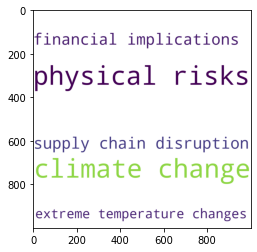

In [9]:
from keyphrase_vectorizers import KeyphraseCountVectorizer  
import matplotlib.pyplot as plt
from wordcloud import WordCloud

vectorizer = KeyphraseCountVectorizer()
keywords = kw_model.extract_keywords(doc, vectorizer = vectorizer)
wc = WordCloud(background_color="white",width=1000,height=1000, max_words=10,relative_scaling=0.5,normalize_plurals=False).generate_from_frequencies(dict(keywords))
plt.imshow(wc)

That's already good improvment compared to the basic `CountVectorizer`.

We can also leverage on the `Part-of-speech` (POS) capabilities from `KeyphraseVectorizers`. For example, if we want to only extract nouns from the document in order to have only keywords and not keyphrases:

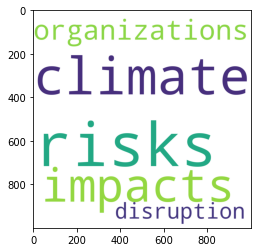

In [16]:
vectorizer = KeyphraseCountVectorizer(pos_pattern='<N. *>')
keywords = kw_model.extract_keywords(doc, vectorizer = vectorizer)
wc = WordCloud(background_color="white",width=1000,height=1000, max_words=10,relative_scaling=0.5,normalize_plurals=False).generate_from_frequencies(dict(keywords))
plt.imshow(wc)

**EXERCISE**: go to the [spacy](https://spacy.io/usage/linguistic-features#pos-tagging) POS tagging website and try to play around with the `pos_pattern`.

### Fine-tuning

As we've mentioned before, we can use the Max Sum Distance or the Maximal MArginal Relevance algorithms to increase the diversification of our resulting keywords / keyphrases. Both algorithms are implemented directly into the `KeyBERT` library:

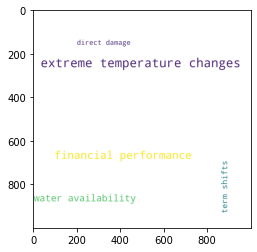

In [25]:
vectorizer = KeyphraseCountVectorizer()
keywords = kw_model.extract_keywords(doc, vectorizer = vectorizer, use_maxsum=True, nr_candidates = 20, top_n = 5)
wc = WordCloud(background_color="white",width=1000,height=1000, max_words=10,relative_scaling=0.5,normalize_plurals=False).generate_from_frequencies(dict(keywords))
plt.imshow(wc)

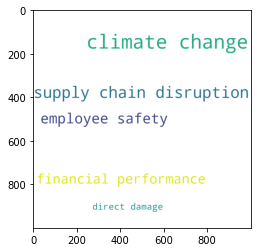

In [26]:
vectorizer = KeyphraseCountVectorizer()
keywords = kw_model.extract_keywords(doc, vectorizer = vectorizer, use_mmr = True, diversity = 0.8)
wc = WordCloud(background_color="white",width=1000,height=1000, max_words=10,relative_scaling=0.5,normalize_plurals=False).generate_from_frequencies(dict(keywords))
plt.imshow(wc)

**EXERCISE**: play around with the `nr_candidates` and the `diversity` parameters and observe the change in the size of the resulting keywords representation in the word cloud.

## Extracting Keywords from IPCC Reports

We've converted the pdf reports to text files, downloaded from the IPCC website.
The first step is in loading the report.

In [85]:
fileObject = open("03_SROCC_Ch01_FINAL.txt", "r")
data = fileObject.read()
data = data.replace("\n", " ")
data = data.split('. ')
print(len(data))
print(data[1000])

3721
Marine heat waves are occurring everywhere across the surface ocean, and are becoming more frequent and more intense as the ocean warms


However, as we can see, the representation is far from being perfect. Transformation from pdf to text is still far from efficient, with sentences being weirdly truncated. Furthemore, for our keywords / keyphrases algorithm extraction to be efficient, we need to start from consistent paragraph that can be summarized efficiently. 

We then need to proceed to further preprocessing steps to group sentences and part of sentences in our initial list into meaningful paragraphs.

### Splitting Text into Meaningful Paragraphs

To regroup the sentences into meaninful paragraphs, we will use a lot of notions we've seen earlier:
- We will transform the sentences in our list into a numerical representation (embedding)
- We will compute the cosine similarity between these sentences
- We will identify the splitting points (part where the main topic discussed differ from previous sentences)
- We will then create meaninful paragraphs based on this splitting points.

#### Embedding

First, we will proceed to the embedding, using `all-MiniLM-L6-v2`.

Let's work with a short subset of the TCFD sentences.

In [102]:
model = SentenceTransformer('all-MiniLM-L6-v2')
for i in data[1010:1020]:
  print(i)
embeddings = model.encode(data[1010:1020])


The more these emissions can be curbed, the more the changes in the ocean and cryosphere can be slowed and limited, reducing future risks and impacts
But humankind is also exposed to the effects of changes triggered by past emissions, including sea level rise that will continue for centuries to come
Improving education and using scientific knowledge alongside local knowledge and Indigenous knowledge can support the development of context-specific options that help communities to adapt to inevitable changes and respond to challenges ahead
 113 Chapter 1 Framing and Context of the Report  FAQ 12 | How will changes in the ocean and cryosphere affect meeting the Sustainable Development Goals?  Ocean and cryosphere change affect our ability to meet the United Nations Sustainable Development Goals (SDGs)
Progress on the SDGs support climate action that will reduce future ocean and cryosphere change, and as well as the adaptation responses to unavoidable changes
There are also trade-offs bet

#### Cosine Similarity

There is a way to see sentence similarities (computed with the cosine similarity we've seen earlier) all at once by creating a similarity matrix:

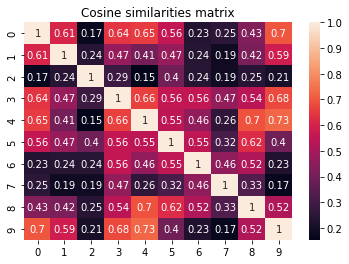

In [100]:
import seaborn as sns

similarities = cosine_similarity(embeddings)
# Let's plot the result we got
sns.heatmap(similarities,annot=True).set_title('Cosine similarities matrix');

#### Identifying Split Points

#### Creating a Paragraphed Representation of the Reports